/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 39779254272.0000 - mae: 178137.7812 - val_loss: 39569518592.0000 - val_mae: 181947.9062
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 39778615296.0000 - mae: 178136.1250 - val_loss: 39568515072.0000 - val_mae: 181945.2969
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 39776989184.0000 - mae: 178131.8594 - val_loss: 39565950976.0000 - val_mae: 181938.7031
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 39772971008.0000 - mae: 178121.6406 - val_loss: 39559823360.0000 - val_mae: 181923.2344
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 39763664896.0000 - mae: 178098.6875 - val_loss: 39546253312.0000 - val_mae: 181889.6406
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 39744704512.0000 - mae: 178052.3438 - val_loss: 39520190464.0000 - val_mae: 181825.9219
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 39709216768.0000 - mae: 177967.9062 - val_loss: 39474397184.

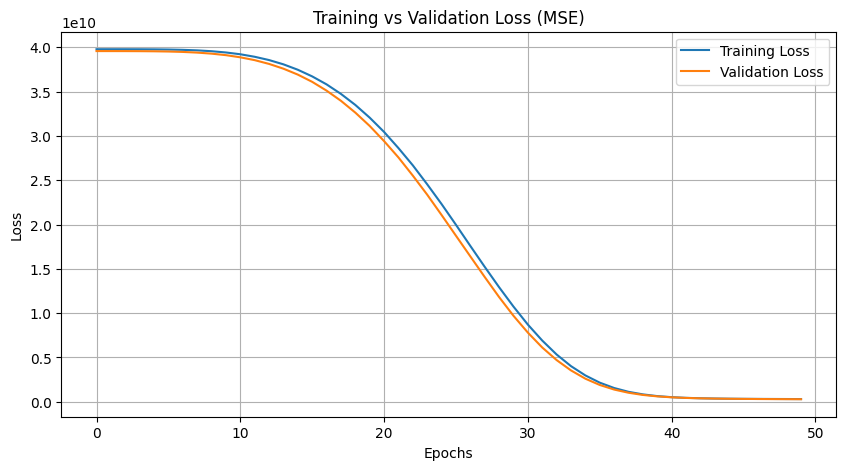

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Example: Suppose X = features (like size, rooms, location encoded), y = house prices
# Replace this with your actual dataset
# For demonstration, let's create synthetic data
np.random.seed(42)
X = np.random.rand(1000, 5) * 100  # 1000 samples, 5 features
y = X[:,0]*3000 + X[:,1]*500 + np.random.rand(1000)*10000  # synthetic target

# 1. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Feature scaling (important for ANN training)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Build ANN model
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear")  # regression output
])

# 4. Compile model
model.compile(optimizer="adam", loss="mean_squared_error", metrics=["mae"])

# 5. Train model
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

# 6. Evaluate model
loss, mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {mae:.2f}")

# 7. Predict sample house prices
predictions = model.predict(X_test[:5])
print("Predicted prices:", predictions.flatten())
print("True prices:", y_test[:5])

# 8. Plot Training vs Validation Loss
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()
